In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [8]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

matplotlib: 3.9.2
numpy     : 1.26.4
tensorflow: 2.19.0
keras     : 3.10.0
sklearn   : 1.5.1
pandas    : 2.2.2
seaborn   : 0.13.2
plotly    : 5.24.1



In [9]:
df = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/commodities.csv")

In [10]:
df.index = pd.to_datetime(df['data'], format = '%Y-%m-%d')

In [11]:
del df['data']

Text(0.5, 0, 'Data')

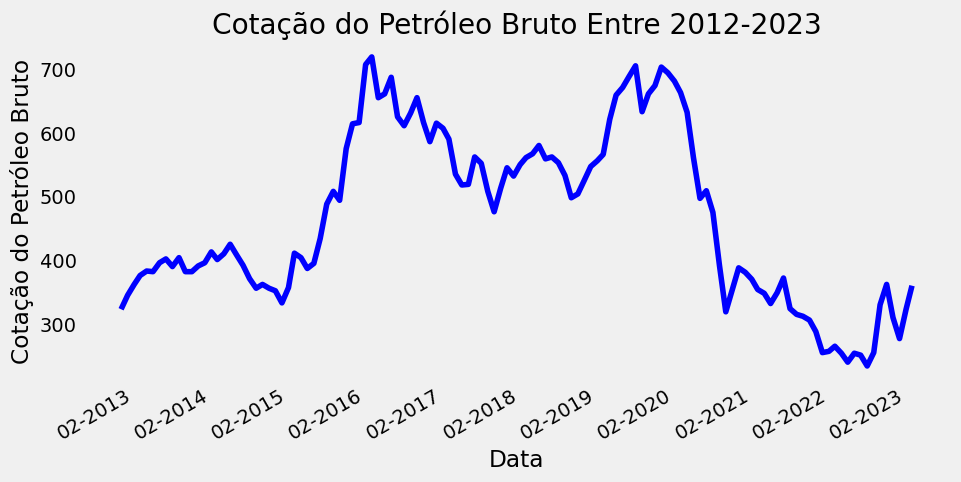

In [12]:
plt.figure(figsize = (10, 5))
plt.grid()
plt.plot(df.index, df['petroleo_bruto'], color = 'blue')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval = 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gcf().autofmt_xdate()
plt.title('Cotação do Petróleo Bruto Entre 2012-2023')
plt.ylabel('Cotação do Petróleo Bruto')
plt.xlabel('Data')

In [13]:
train_size = int(len(df) * 0.8)
teste_size = len(df) - train_size

In [14]:
train = df.iloc[0:train_size]

In [15]:
test = df.iloc[train_size:len(df)]

In [16]:
variaveis_preditoras = ['minerio_ferro',
                        'ouro',
                        'arroz',
                        'feijao',
                        'milho',
                        'soja',
                        'trigo',
                        'cafe',
                        'algodao',
                        'umidade']

In [17]:
scaler_preditores = MinMaxScaler()

In [18]:
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [19]:
train.loc[:, variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [20]:
test.loc[:, variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [21]:
scaler_target = MinMaxScaler()

In [22]:
scaler_target = scaler_target.fit(train[['petroleo_bruto']])

In [23]:
train['petroleo_bruto'] = scaler_target.transform(train[['petroleo_bruto']])

In [24]:
test['petroleo_bruto'] = scaler_target.transform(test[['petroleo_bruto']])

In [25]:
def createDataset(X, y, time_steps):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

In [26]:
time_steps = 3

In [27]:
X_train, y_train = createDataset(train, train.petroleo_bruto, time_steps)

In [28]:
X_test, y_test = createDataset(test, test.petroleo_bruto, time_steps)

In [30]:
modelo_lstm = tf.keras.Sequential()
modelo_lstm.add(tf.keras.layers.LSTM(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_lstm.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_lstm.add(tf.keras.layers.Dense(units = 1))

In [31]:
modelo_lstm.compile(loss = 'mse', optimizer = 'adam')

In [32]:
modelo_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,809 (280.50 KB)

 Trainable params: 71,809 (280.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
%%time
modelo_lstm_history = modelo_lstm.fit(X_train,
                                        y_train,
                                        epochs = 100,
                                        batch_size = 32,
                                        validation_split = 0.1,
                                        shuffle = False)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - loss: 0.2736 - val_loss: 0.0577
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1107 - val_loss: 0.0320
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0358 - val_loss: 0.0700
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0236 - val_loss: 0.1407
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0515 - val_loss: 0.1807
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0671 - val_loss: 0.1625
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0544 - val_loss: 0.1190
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0408 - val_loss: 0.0800
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0272 - val_loss: 0.0563
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0220 - val_loss: 0.0452
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0209 - val_loss: 0.0418
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0212 - val_l

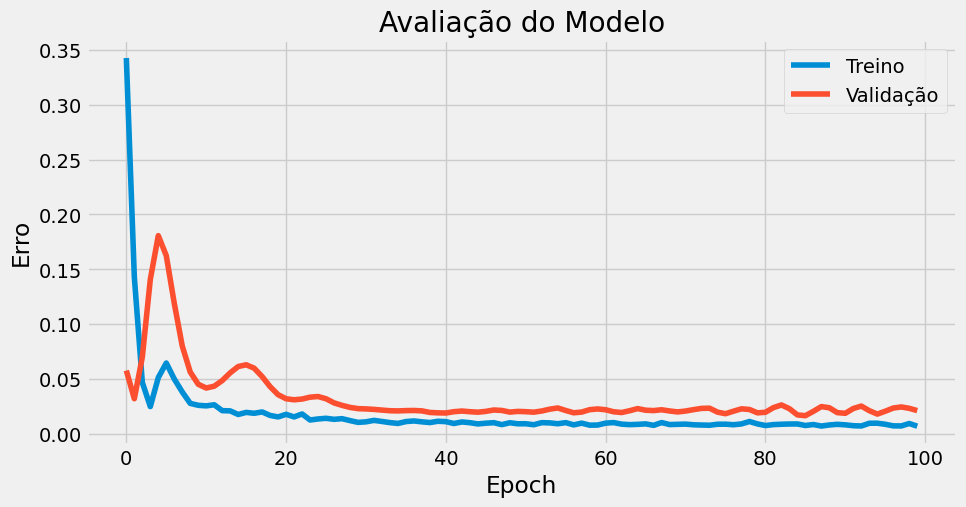

In [35]:
plt.plot(modelo_lstm_history.history['loss'])
plt.plot(modelo_lstm_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [36]:
y_pred = modelo_lstm.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


In [37]:
y_pred

array([[0.16785386],
       [0.1788661 ],
       [0.18861382],
       [0.19789867],
       [0.1503877 ],
       [0.10802449],
       [0.08191016],
       [0.07739958],
       [0.06085487],
       [0.05441065],
       [0.04425315],
       [0.04996634],
       [0.06626683],
       [0.08911103],
       [0.11201531],
       [0.09788325],
       [0.0476702 ],
       [0.04776519],
       [0.13876878],
       [0.21240227],
       [0.20787661],
       [0.1750972 ]], dtype=float32)

In [38]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1))

In [39]:
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

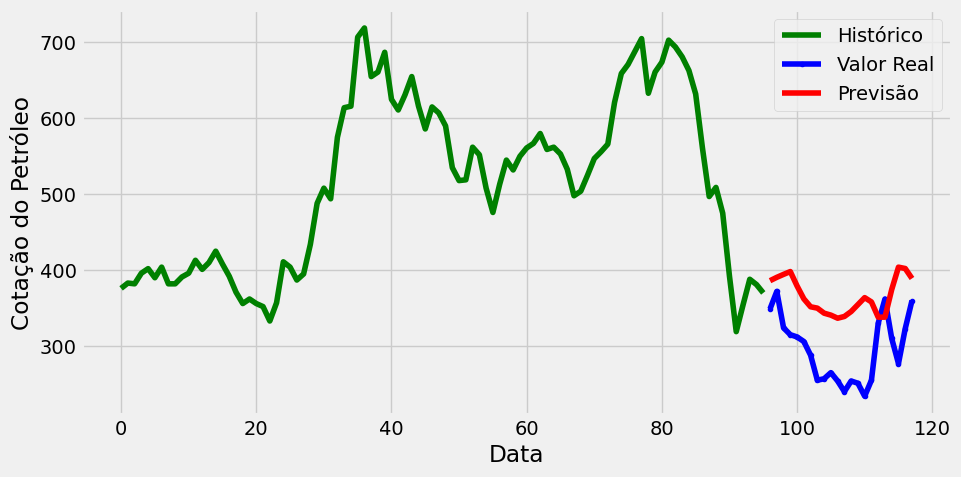

In [41]:
plt.plot(np.arange(0, len(y_train)),
         y_train_inv,
         color = 'green',
         label = 'Histórico')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_test_inv,
                color = 'blue',
                marker = '.',
                label = 'Valor Real')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_pred_inv,
                color = 'red',
                label = 'Previsão')

plt.ylabel('Cotação do Petróleo')
plt.xlabel('Data')
plt.legend()
plt.show()

In [42]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [43]:
MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

MAE_mlp = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.38095238095238093
MAE: 72.49574141068892
MSE: 6309.880141385069
RMSE: 79.43475398957983
EVS Score: 0.23819855949852298
